сначала я скачал и инпортировал датасет memradar-price-index-monthly.csv где находятся цены оперативной памяти в течение время

In [1]:
import polars as pl
from pathlib import Path

FILE = Path(
    #"C:\\GitHub\\tec-data-analisis\\lab02\\task\\memradar-price-index-monthly.csv"
    "/home/qjaricalizaya/work_university/tec-data-analisis/lab02/task/memradar-price-index-monthly.csv"
)

data = pl.scan_csv(
    source=FILE,
    truncate_ragged_lines=True
)

data_schema = data.collect_schema()
height = data.select(pl.len()).collect()

#print(data.collect())
print(f"схема: {data_schema}")
print(f"количество строк: {height["len"][0]}")


схема: Schema({'segment': String, 'month': String, 'median_price_usd': Float64, 'median_usd_per_gb': Float64, 'product_count': Int64})
количество строк: 244


дальше я проанализировал пропуски и рассчитайте долю пропусков для каждого столбца.

In [2]:
print( data.select(pl.all().is_null().mean() ).collect() )

shape: (1, 5)
┌─────────┬───────┬──────────────────┬───────────────────┬───────────────┐
│ segment ┆ month ┆ median_price_usd ┆ median_usd_per_gb ┆ product_count │
│ ---     ┆ ---   ┆ ---              ┆ ---               ┆ ---           │
│ f64     ┆ f64   ┆ f64              ┆ f64               ┆ f64           │
╞═════════╪═══════╪══════════════════╪═══════════════════╪═══════════════╡
│ 0.0     ┆ 0.0   ┆ 0.0              ┆ 0.0               ┆ 0.0           │
└─────────┴───────┴──────────────────┴───────────────────┴───────────────┘


в моем случае не было null строки, поэтому я получил 0.0 в всех столбах

как видно в схеме, метод scan_csv() некорректно обратил типы данных
 Schema(
        {
        'segment': String, 
        'month': String, 
        'median_price_usd': Float64, 
        'median_usd_per_gb': Float64, 
        'product_count': Int64
        }
    )

в схеме есть month (месяц) как string а нет как time. поэтому я сейчас это исправлю

In [3]:
data = data.with_columns(
    pl.col("month").str.to_date("%Y-%m")
)
data.collect_schema()

Schema([('segment', String),
        ('month', Date),
        ('median_price_usd', Float64),
        ('median_usd_per_gb', Float64),
        ('product_count', Int64)])

In [4]:
data.collect()

segment,month,median_price_usd,median_usd_per_gb,product_count
str,date,f64,f64,i64
"""ddr5""",2022-06-01,271.1,6.9916,10
"""ddr5""",2022-07-01,319.99,6.7344,11
"""ddr5""",2022-08-01,238.66,6.5594,10
"""ddr5""",2022-09-01,246.05,7.2984,16
"""ddr5""",2022-10-01,257.49,7.305,18
…,…,…,…,…
"""sata_ssd""",2026-04-01,234.5,0.2334,27
"""sata_ssd""",2026-05-01,261.25,0.2243,29
"""sata_ssd""",2026-06-01,229.46,0.2077,30


дальше я создал матрицу рассеяния

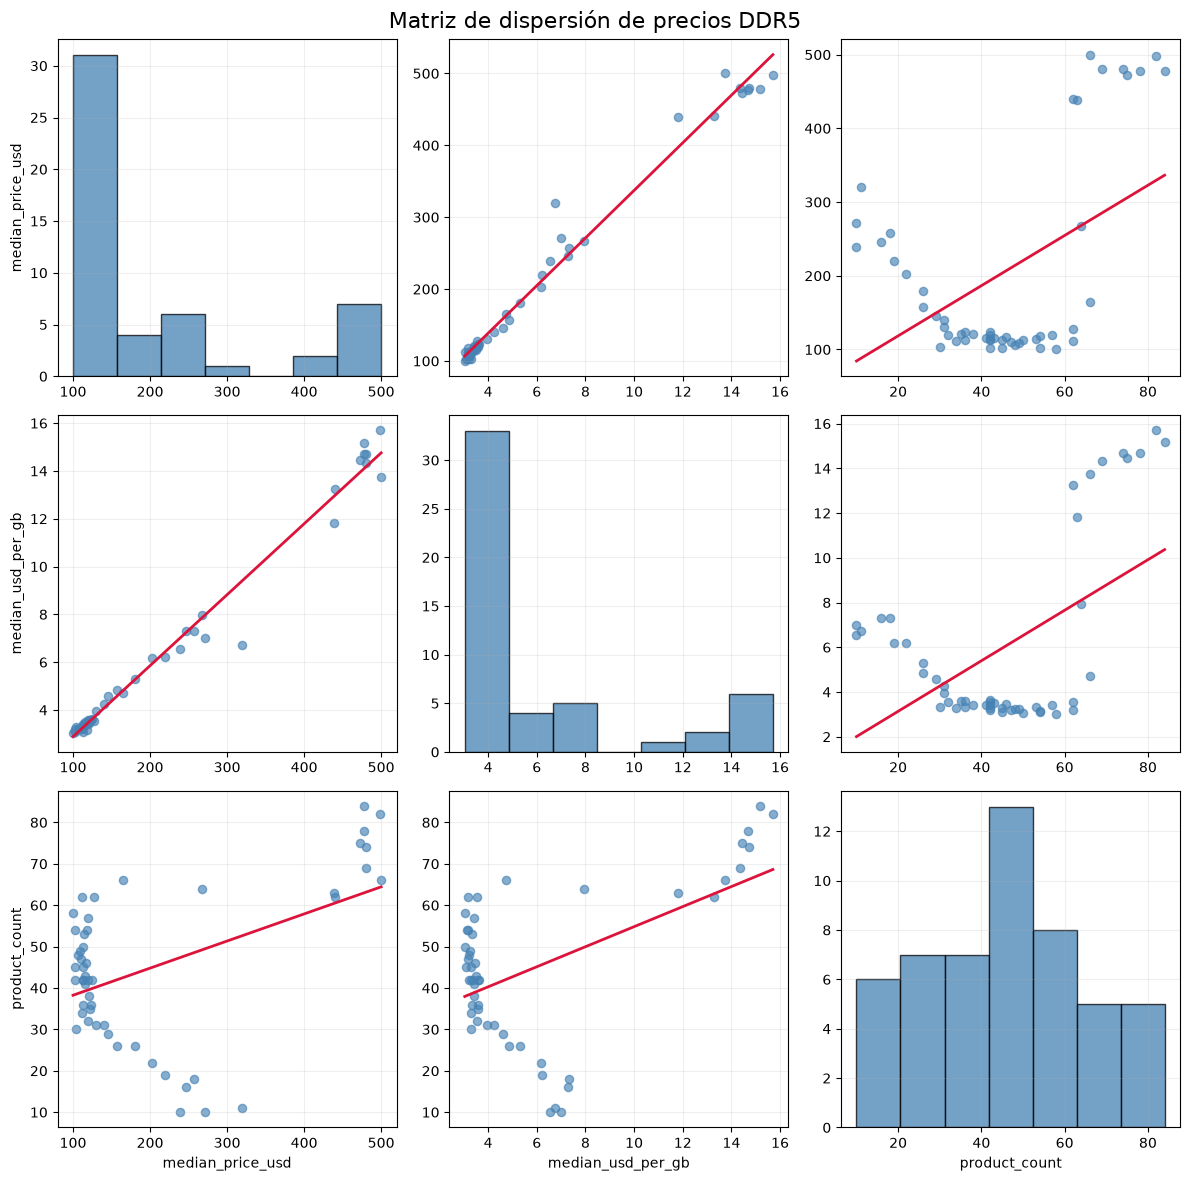

In [5]:
import numpy as np
import matplotlib.pyplot as plt

columnas = [
    "median_price_usd",
    "median_usd_per_gb",
    "product_count",
]

datos_grafica = (
    data
    .filter(
        pl.col("segment").str.to_lowercase() == "ddr5"
    )
    .select([
        pl.col(columna).cast(pl.Float64)
        for columna in columnas
    ])
    .drop_nulls()
    .collect()
)

numero_columnas = len(columnas)

fig, axes = plt.subplots(
    numero_columnas,
    numero_columnas,
    figsize=(4 * numero_columnas, 4 * numero_columnas)
)

for fila, columna_y in enumerate(columnas):
    for columna, columna_x in enumerate(columnas):

        ax = axes[fila, columna]

        x = datos_grafica.get_column(columna_x).to_numpy()
        y = datos_grafica.get_column(columna_y).to_numpy()

        # Diagonal: histograma
        if fila == columna:
            ax.hist(
                x,
                bins="auto",
                color="steelblue",
                edgecolor="black",
                alpha=0.75
            )

        # Fuera de la diagonal: dispersión y tendencia
        else:
            ax.scatter(
                x,
                y,
                color="steelblue",
                alpha=0.65,
                s=35
            )

            valores_validos = np.isfinite(x) & np.isfinite(y)

            x_validos = x[valores_validos]
            y_validos = y[valores_validos]

            if (
                len(x_validos) >= 2
                and len(np.unique(x_validos)) > 1
            ):
                pendiente, intercepto = np.polyfit(
                    x_validos,
                    y_validos,
                    1
                )

                x_linea = np.linspace(
                    x_validos.min(),
                    x_validos.max(),
                    100
                )

                y_linea = pendiente * x_linea + intercepto

                ax.plot(
                    x_linea,
                    y_linea,
                    color="crimson",
                    linewidth=2
                )

        # Etiquetas exteriores
        if fila == numero_columnas - 1:
            ax.set_xlabel(columna_x)

        if columna == 0:
            ax.set_ylabel(columna_y)

        ax.grid(alpha=0.2)

fig.suptitle(
    "Matriz de dispersión de precios DDR5",
    fontsize=16
)

plt.tight_layout()
plt.show()

дальше я создал график временного ряда

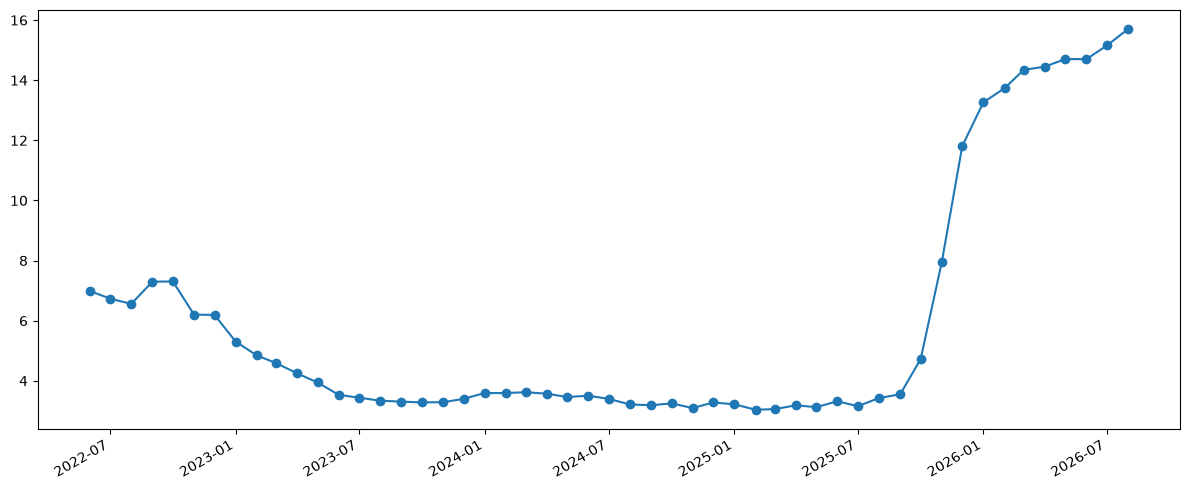

In [6]:
ddr5_data = data.filter(pl.col("segment").str.to_lowercase() == "ddr5" ).select(pl.all()).collect()

#print(ddr5_data)

x = ddr5_data.get_column("month")
y = ddr5_data.get_column("median_usd_per_gb")


fig , ax = plt.subplots(figsize=(12, 5))
ax.plot( x,  y , marker="o")


fig.autofmt_xdate()
plt.tight_layout()
plt.show()